# Iterative Radiomics-Guided Region Growing Algorithm



## Objective

Implement an iterative region growing algorithm using voxel-based PyRadiomics features on SPECT tumor images.

## Algorithm Overview

1. **Load SPECT DICOM Study**: Import full 3D DICOM series using SimpleITK
2. **Extract & Display Coronal Slice**: Select a specific coronal plane for analysis
3. **Define Working ROI**: Crop the coronal slice to the region of interest
4. **Create Initial Lesion Mask**: Apply intensity thresholding to identify potential lesion
5. **Compute Reference Radiomic Map**: Extract voxel-based Median map inside initial ROI (ROI0)
6. **Establish Statistical Limits**: Use ROI0 distribution as fixed reference (mean ± k*std)
7. **Iterative Region Growing**:
   - Dilate current ROI to generate candidate voxels (corona)
   - Compute voxel-based Median for dilated region
   - Classify each voxel: accept if within statistical bounds
   - Update ROI with accepted voxels
   - Repeat for N iterations
8. **Generate Results & Visualizations**

## Key Implementation Details

- **Radiomic Feature**: `firstorder.Median` (voxel-based)
- **Reference Distribution**: Fixed throughout all iterations
- **PyRadiomics Coordinate Handling**: Automatic reconstruction from bounding-box to full-image coordinates
- **Configurable Parameters**: Threshold percentage, k-value, number of iterations

In [43]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import binary_dilation
from radiomics import featureextractor
import matplotlib.patches as patches
import pydicom

## Variable parameters

### 1. **Threshold**
### 2. **k_value**
### 3. **Caracteristica radiomica**

In [44]:
# ==================================================================================================
# 2. CONFIGURATION & PARAMETERS
# ==================================================================================================

# Data paths
DATA_DIR = Path("PSMAB37")
SPECT_DIR = DATA_DIR / "SPECT"

# Imaging parameters
CORONAL_SLICE = 137
ROI_CROP = (220, 140)        # (row_start, col_start)

# Thresholding parameters
THRESHOLD_PERCENTILE = 0.65  # Initial ROI = 65% of maximum intensity

# --------------------------------------------------------------------------------------------------
# Radiomic feature
# --------------------------------------------------------------------------------------------------

FEATURE_CLASS = "ngtdm"  # Options: "firstorder", "ngtdm"
FEATURE_NAME = "Coarseness"  # Default feature for the growing experiments
FEATURE_KEY = f"original_{FEATURE_CLASS}_{FEATURE_NAME}"

# --------------------------------------------------------------------------------------------------
# Growing strategy
# --------------------------------------------------------------------------------------------------

GROWING_METHOD = "A"  # "A" = global radiomic evolution, "B" = hybrid global/local radiomics
ACCEPTANCE_METHOD = "percentage"  # Options: "relative", "percentage"
EPSILON = 0.05
THRESHOLD_PERCENT = 1
MAX_DILATIONS = 15

# Backward-compatible alias kept for older cells that may still reference it.
NUM_ITERATIONS = MAX_DILATIONS

print("Configuration loaded:")
print(f"  - SPECT directory: {SPECT_DIR}")
print(f"  - Coronal slice: {CORONAL_SLICE}")
print(f"  - ROI crop offset: {ROI_CROP}")
print(f"  - Radiomic feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Growing method: {GROWING_METHOD}")
print(f"  - Acceptance method: {ACCEPTANCE_METHOD}")
print(f"  - EPSILON: {EPSILON}")
print(f"  - THRESHOLD_PERCENT: {THRESHOLD_PERCENT}")
print(f"  - MAX_DILATIONS: {MAX_DILATIONS}")

Configuration loaded:
  - SPECT directory: PSMAB37\SPECT
  - Coronal slice: 137
  - ROI crop offset: (220, 140)
  - Radiomic feature: ngtdm.Coarseness
  - Growing method: A
  - Acceptance method: percentage
  - EPSILON: 0.05
  - THRESHOLD_PERCENT: 1
  - MAX_DILATIONS: 15


In [45]:
# ==============================================================================
# PyRadiomics extraction parameters
# ==============================================================================

KERNEL_RADIUS = 1           # Radius for voxel-based extraction
DISTANCES = [1]             # Neighbor distances for texture matrices
WEIGHTING_NORM = None       # None, "manhattan", "euclidean", "infinity"

# Optional preprocessing
NORMALIZE = False
REMOVE_OUTLIERS = None

# Gray level discretization
BIN_WIDTH = 25              # Fixed Bin Size (default)

# Voxel-based extraction
KERNEL_RADIUS = 1           # Default
MASKED_KERNEL = True        # Default

# Texture computation
DISTANCES = [1]             # Default
WEIGHTING_NORM = None       # Default

# Image preprocessing
NORMALIZE = False           # Default
REMOVE_OUTLIERS = None      # Default

# Resampling
RESAMPLED_PIXEL_SPACING = None   # Default
INTERPOLATOR = sitk.sitkBSpline  # Default

## Stage 1: Data Loading & Preparation

In [46]:
def compute_global_feature(mask_array):
    sitk_mask = sitk.GetImageFromArray(mask_array[np.newaxis, :, :].astype(np.uint8))
    result = extractor.execute(sitk_img, sitk_mask, voxelBased=False)
    return float(result[FEATURE_KEY]), result


def compute_voxel_feature_map(mask_array):
    sitk_mask = sitk.GetImageFromArray(mask_array[np.newaxis, :, :].astype(np.uint8))
    result = extractor.execute(sitk_img, sitk_mask, voxelBased=True)
    voxel_map, _ = reconstruct_voxel_map(result, roi_img.shape, FEATURE_KEY)
    return voxel_map, result


def evaluate_acceptance(candidate_value, reference_value):
    if not np.isfinite(candidate_value) or not np.isfinite(reference_value):
        return False, np.nan, np.nan, np.nan, np.nan, np.nan

    denominator = max(abs(reference_value), np.finfo(float).eps)
    relative_difference = abs(candidate_value - reference_value) / denominator
    percentage_difference = 100.0 * relative_difference

    if ACCEPTANCE_METHOD == "relative":
        accepted = relative_difference < EPSILON
        metric_value = relative_difference
        metric_name = "Relative difference"
        threshold_value = EPSILON
    elif ACCEPTANCE_METHOD == "percentage":
        accepted = percentage_difference < THRESHOLD_PERCENT
        metric_value = percentage_difference
        metric_name = "Percentage difference"
        threshold_value = THRESHOLD_PERCENT
    else:
        raise ValueError(f"Unknown acceptance method: {ACCEPTANCE_METHOD}")

    return accepted, metric_value, metric_name, threshold_value, relative_difference, percentage_difference


def _summary_stats(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0 or np.all(np.isnan(values)):
        return np.nan, np.nan, np.nan
    return float(np.nanmean(values)), float(np.nanmin(values)), float(np.nanmax(values))


def _run_growth_loop(candidate_value_provider, method_label):
    roi_current = mask0.copy()
    rejected_forever = np.zeros_like(roi_current, dtype=bool)

    results = []
    history = []
    stopping_reason = f"Reached MAX_DILATIONS ({MAX_DILATIONS})"

    print(f"Starting {method_label} growing ({MAX_DILATIONS} dilations max)...\n")

    for iteration in range(1, MAX_DILATIONS + 1):
        #*_________________________________________________________________
        feature_before, _ = compute_global_feature(roi_current)
        reference_feature = feature_before
        
        print(f"Iteración {iteration}: referencia = {reference_feature:.6f}")
        
        #*_________________________________________________________________
        
        roi_dilated = binary_dilation(roi_current)

        # Exclude voxels that were permanently rejected
        corona = roi_dilated & (~roi_current) & (~rejected_forever)

        candidate_positions = np.argwhere(corona)

        if candidate_positions.size == 0:
            stopping_reason = "No candidate voxels after dilation"
            break

        candidate_values, feature_map = candidate_value_provider(roi_current, roi_dilated, corona, candidate_positions)

        accepted_mask = np.zeros_like(roi_current, dtype=bool)
        candidate_metrics = []
        candidate_relative_differences = []
        candidate_percentage_differences = []
        accepted_flags = []
        metric_name = None
        threshold_value = np.nan

        for (row, col), candidate_value in zip(candidate_positions, candidate_values):
            accepted, metric_value, metric_name, threshold_value, relative_difference, percentage_difference = evaluate_acceptance(
                candidate_value,
                reference_feature,
            )
            accepted_flags.append(accepted)
            candidate_metrics.append(metric_value)
            candidate_relative_differences.append(relative_difference)
            candidate_percentage_differences.append(percentage_difference)
            if accepted:
                accepted_mask[row, col] = True

        # Permanently store rejected voxels
        mask_rejected = corona & (~accepted_mask)
        rejected_forever |= mask_rejected
        
        
        roi_new = roi_current | accepted_mask
        
        feature_after, _ = compute_global_feature(roi_new)

        accepted_count = int(accepted_mask.sum())
        rejected_count = int(corona.sum()) - accepted_count
        candidate_metric_mean, candidate_metric_min, candidate_metric_max = _summary_stats(candidate_metrics)
        size_increase = int(roi_new.sum() - roi_current.sum())

        results.append({
            "Iteration": iteration,
            "Candidate Voxels": int(corona.sum()),
            "Accepted Voxels": accepted_count,
            "Rejected Voxels": rejected_count,
            "Current ROI Size": int(roi_current.sum()),
            "New ROI Size": int(roi_new.sum()),
            "Cumulative Lesion Size": int(roi_new.sum()),
            "Feature Before": feature_before,
            "Feature After": feature_after,
            "Feature Change": float(feature_after - feature_before),
            "Acceptance Metric Mean": candidate_metric_mean,
            "Acceptance Metric Min": candidate_metric_min,
            "Acceptance Metric Max": candidate_metric_max,
            "Acceptance Threshold": threshold_value,
        })

        history.append({
            "iteration": iteration,
            "roi_current": roi_current.copy(),
            "roi_dilated": roi_dilated.copy(),
            "corona": corona.copy(),
            "mask_accepted": accepted_mask.copy(),
            "candidate_positions": candidate_positions.copy(),
            "candidate_values": np.asarray(candidate_values, dtype=float).copy(),
            "candidate_metrics": np.asarray(candidate_metrics, dtype=float).copy(),
            "candidate_relative_differences": np.asarray(candidate_relative_differences, dtype=float).copy(),
            "candidate_percentage_differences": np.asarray(candidate_percentage_differences, dtype=float).copy(),
            "accepted_flags": np.asarray(accepted_flags, dtype=bool).copy(),
            "feature_map": None if feature_map is None else feature_map.copy(),
            "feature_before": feature_before,
            "feature_after": feature_after,
            "acceptance_metric_name": metric_name,
            "acceptance_threshold": threshold_value,
            "mask_rejected": mask_rejected.copy(),
            "rejected_forever": rejected_forever.copy(),
            "roi_after": roi_new.copy(),
        })

        print(
            f"Iter {iteration:2d}: ROI {roi_current.sum():4d} → {roi_new.sum():4d} | "
            f"Candidates: {corona.sum():4d} | Accepted: {accepted_count:4d} | Rejected: {rejected_count:4d} | "
            f"Growth: {size_increase:+4d}"
        )

        roi_current = roi_new

        if accepted_count == 0:
            stopping_reason = "No voxels satisfied the acceptance criterion"
            break

    roi_final = roi_current.copy()
    return roi_final, results, history, stopping_reason


def _method_a_candidate_values(roi_current, roi_dilated, corona, candidate_positions):
    candidate_values = []
    for row, col in candidate_positions:
        trial_roi = roi_current.copy()
        trial_roi[row, col] = True
        candidate_value, _ = compute_global_feature(trial_roi)
        candidate_values.append(candidate_value)
    return np.asarray(candidate_values, dtype=float), None


def _method_b_candidate_values(roi_current, roi_dilated, corona, candidate_positions):
    feature_map, _ = compute_voxel_feature_map(roi_dilated)
    candidate_values = feature_map[corona]
    return np.asarray(candidate_values, dtype=float), feature_map


def run_region_growing():
    if GROWING_METHOD == "A":
        return _run_growth_loop(_method_a_candidate_values, "Method A")
    if GROWING_METHOD == "B":
        return _run_growth_loop(_method_b_candidate_values, "Method B")
    raise ValueError(f"Unknown growing method: {GROWING_METHOD}")


print("✓ Growing helpers defined")

✓ Growing helpers defined


In [47]:
# Load SPECT DICOM series
reader = sitk.ImageSeriesReader()
files = reader.GetGDCMSeriesFileNames(str(SPECT_DIR))
reader.SetFileNames(files)
spect_img = reader.Execute()# este es el objeto de imagen de SPECT en SimpleITK

spect_array = sitk.GetArrayFromImage(spect_img)# este es la imagen de SPECT en un array de numpy

print(f" SPECT series loaded")
print(f"  - Shape: {spect_array.shape}")#Formato: (z, y, x) para imágenes 3D
print(f"  - Size: {spect_img.GetSize()}")#Formato: (x, y, z) para imágenes 3D
print(f"  - Spacing: {spect_img.GetSpacing()}") #Devuelve el tamaño físico de cada voxel en milímetros (x_spacing, y_spacing, z_spacing)
print(f"  - Range: [{spect_array.min():.2f}, {spect_array.max():.2f}]") #Muestra los valores mínimo y máximo de intensidad de la imagen.

 SPECT series loaded
  - Shape: (299, 256, 256)
  - Size: (256, 256, 299)
  - Spacing: (2.734375, 2.734375, 3.270000022529765)
  - Range: [0.00, 52344.30]


 Coronal slice extracted and processed
  - Coronal slice index: 137
  - Full coronal shape: (299, 256)
  - Working ROI shape: (79, 116)
  - ROI intensity range: [0.00, 19446.12]


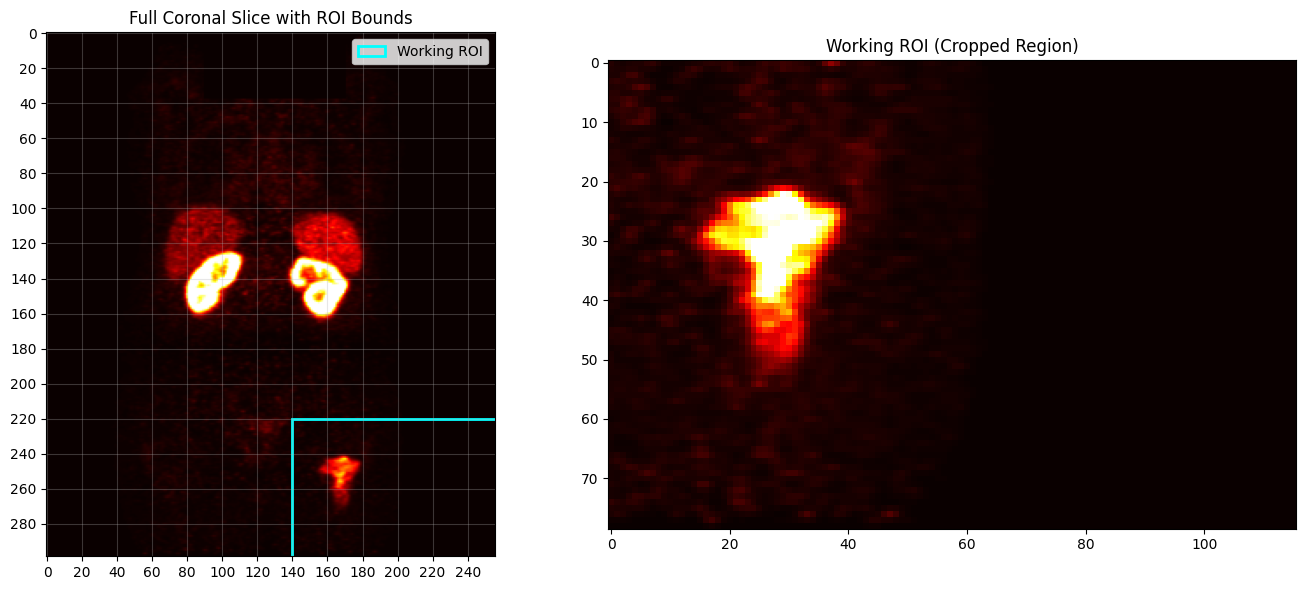

In [48]:
# Extract and display coronal slice
coronal_raw = spect_array[:, CORONAL_SLICE, :]#
coronal_vis = np.fliplr(np.rot90(coronal_raw, 2))# SE ROTAN 180 GRADOS Y SE VOLTEA HORIZONTALMENTE PARA QUE LA IMAGEN CORONAL SE VISUALICE CORRECTAMENTE


# Crop to working region
roi_img = coronal_vis[ROI_CROP[0]:, ROI_CROP[1]:]# se recorta la imagen coronal para obtener la región de interés (ROI) a partir de las coordenadas especificadas en ROI_CROP

print(f" Coronal slice extracted and processed")
print(f"  - Coronal slice index: {CORONAL_SLICE}")
print(f"  - Full coronal shape: {coronal_vis.shape}")
print(f"  - Working ROI shape: {roi_img.shape}")
print(f"  - ROI intensity range: [{roi_img.min():.2f}, {roi_img.max():.2f}]")

# Visualize working ROI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full coronal image
axes[0].imshow(
    coronal_vis,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(coronal_vis, 99)
)

# Coordinate grid
axes[0].set_xticks(np.arange(0, coronal_vis.shape[1], 20))
axes[0].set_yticks(np.arange(0, coronal_vis.shape[0], 20))
axes[0].grid(True, alpha=0.3)

# ROI rectangle
roi_rect = patches.Rectangle(
    (ROI_CROP[1], ROI_CROP[0]),               # (x, y)
    coronal_vis.shape[1] - ROI_CROP[1],      # width
    coronal_vis.shape[0] - ROI_CROP[0],      # height
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    label="Working ROI"
)

axes[0].add_patch(roi_rect)

axes[0].set_title("Full Coronal Slice with ROI Bounds")
axes[0].legend()

# Cropped ROI
axes[1].imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

axes[1].set_title("Working ROI (Cropped Region)")
axes[1].axis("on")

plt.tight_layout()
plt.show()

### ____________________________________________________________________________-

✓ Manual segmentation loaded
  - Segmented voxels (3D): 4828
  - Segmented pixels in ROI: 318


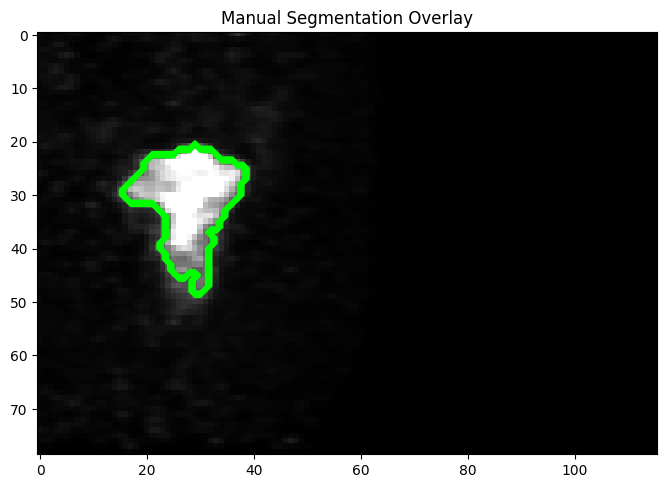

In [49]:
# ==============================================================================
# ! Stage 1.5: Load Manual Segmentation (DICOM SEG)
# ==============================================================================

SEG_PATH = DATA_DIR / "SEGMENTATIONS" / "1-1.dcm"

def load_manual_segmentation(
    seg_path,
    spect_dir,
    spect_array,
    coronal_slice,
    roi_crop
):
    """
    Load DICOM SEG, reconstruct full 3D segmentation volume,
    extract the same coronal plane used by the algorithm,
    and apply identical visualization transforms and ROI crop.
    """

    # Load SEG object
    seg = pydicom.dcmread(str(seg_path))
    seg_array = seg.pixel_array.astype(np.uint8)

    # Build UID -> slice index map from SPECT series
    spect_files = sorted(Path(spect_dir).glob("*.dcm"))

    uid_to_slice = {}

    for idx, f in enumerate(spect_files):

        ds = pydicom.dcmread(
            str(f),
            stop_before_pixels=True
        )

        uid_to_slice[ds.SOPInstanceUID] = idx

    # Determine which SPECT slice corresponds to each SEG frame
    seg_slices = []

    for frame in seg.PerFrameFunctionalGroupsSequence:

        uid = (
            frame.DerivationImageSequence[0]
            .SourceImageSequence[0]
            .ReferencedSOPInstanceUID
        )

        if uid in uid_to_slice:
            seg_slices.append(uid_to_slice[uid])

    # Reconstruct full 3D segmentation volume
    manual_mask_3d = np.zeros_like(
        spect_array,
        dtype=np.uint8
    )

    for frame_idx, spect_idx in enumerate(seg_slices):
        manual_mask_3d[spect_idx] = seg_array[frame_idx]

    # Extract same coronal plane
    manual_coronal_raw = manual_mask_3d[:, coronal_slice, :]

    # Apply same visualization orientation
    manual_coronal_vis = np.flipud(
        np.fliplr(
            np.rot90(manual_coronal_raw, 2)
        )
    )

    # Apply same ROI crop
    manual_mask_roi = manual_coronal_vis[
        roi_crop[0]:,
        roi_crop[1]:
    ]

    return (
        manual_mask_3d,
        manual_coronal_vis,
        manual_mask_roi
    )

# Load manual segmentation
manual_mask_3d, manual_coronal_vis, manual_mask_roi = (
    load_manual_segmentation(
        SEG_PATH,
        SPECT_DIR,
        spect_array,
        CORONAL_SLICE,
        ROI_CROP
    )
)

print("✓ Manual segmentation loaded")
print(f"  - Segmented voxels (3D): {manual_mask_3d.sum()}")
print(f"  - Segmented pixels in ROI: {manual_mask_roi.sum()}")

# Visual verification

plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

plt.contour(
    manual_mask_roi,
    colors="lime",
    linewidths=2
)

plt.title("Manual Segmentation Overlay")
plt.show()

### _____________________________________________________________________________________________

## Stage 2: Initial Lesion Mask (ROI0)

 Initial mask (ROI0) created
  - Threshold: 65% of max = 12639.98
  - Mask size: 76 voxels


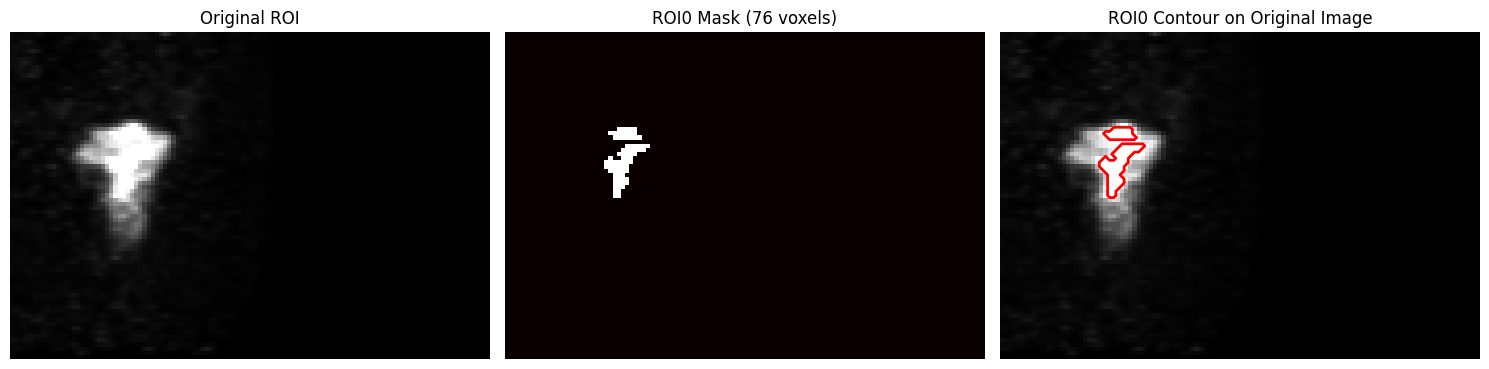

In [50]:
# Create initial lesion mask (ROI0)
threshold = THRESHOLD_PERCENTILE * roi_img.max() 
mask0 = roi_img > threshold # todo voxel con intensidad mayor al umbral se considera parte de la lesión y se marca como True en la máscara binaria mask0

print(f" Initial mask (ROI0) created")
print(f"  - Threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max = {threshold:.2f}")
print(f"  - Mask size: {mask0.sum()} voxels")

# Visualize initial mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(mask0, cmap="hot")
axes[1].set_title(f"ROI0 Mask ({mask0.sum()} voxels)")
axes[1].axis('off')

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].set_title("ROI0 Contour on Original Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 3: PyRadiomics Setup & Utility Functions

## Initialize PyRadiomics feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()  # Crear una instancia del extractor de PyRadiomics con la configuración por defecto
extractor.disableAllFeatures()  # Desactivar todas las características para evitar cálculos innecesarios
extractor.enableFeaturesByName(**{FEATURE_CLASS: [FEATURE_NAME]})  # Habilitar únicamente la característica especificada (ej. firstorder: Median)

print(f"✓ PyRadiomics extractor initialized") 
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")  
print(f"  - Voxel-based extraction enabled") 

In [51]:
# ==============================================================================
# Initialize PyRadiomics feature extractor
# ==============================================================================

settings = {
    "binWidth": BIN_WIDTH,
    "kernelRadius": KERNEL_RADIUS,
    "distances": DISTANCES,
    "weightingNorm": WEIGHTING_NORM,
    "normalize": NORMALIZE
}

if REMOVE_OUTLIERS is not None:
    settings["removeOutliers"] = REMOVE_OUTLIERS

extractor = featureextractor.RadiomicsFeatureExtractor(**settings)

# Enable only the desired feature
extractor.disableAllFeatures()
extractor.enableFeaturesByName(
    **{FEATURE_CLASS: [FEATURE_NAME]}
)

print("✓ PyRadiomics extractor initialized")
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Voxel-based extraction enabled")
print("  - Extraction settings:")
print(f"      binWidth        = {BIN_WIDTH}")
print(f"      kernelRadius    = {KERNEL_RADIUS}")
print(f"      distances       = {DISTANCES}")
print(f"      weightingNorm   = {WEIGHTING_NORM}")
print(f"      normalize       = {NORMALIZE}")
print(f"      removeOutliers  = {REMOVE_OUTLIERS}")


✓ PyRadiomics extractor initialized
  - Feature: ngtdm.Coarseness
  - Voxel-based extraction enabled
  - Extraction settings:
      binWidth        = 25
      kernelRadius    = 1
      distances       = [1]
      weightingNorm   = None
      normalize       = False
      removeOutliers  = None


In [52]:
def reconstruct_voxel_map(result_dict, reference_shape, feature_key):
    """
    result_dict: diccionario de resultados de PyRadiomics que contiene la característica extraída y la bounding box
    reference_shape: la forma de la imagen original
    feature_key: clave de la característica en result_dict (ej. "original_firstorder_M
    
    Tomar el mapa radiomico (que viene en bounding box) y colocarlo de nuevo en 
    la imagen original. ME DA UN ARRAY CON el mapa radiomico voxel-based reubicado en el sistema original de la imagen (80×60), lo que 
    no esta en el bounding box esta llenos de ceros sin filtrar aun con la mascara
    """
    bbox_key = "diagnostics_Mask-original_BoundingBox"  # variable donde PyRadiomics guarda la bounding box
    if bbox_key not in result_dict:  # verifica que la bounding box esté presente en el resultado
        raise ValueError(f"Bounding box not found in result. Available keys: {result_dict.keys()}")  # lanza error si falta
    
    bbox = result_dict[bbox_key]  # extrae la tupla bounding box
    x, y, z, sx, sy, sz = bbox  # desempaqueta las coordenadas y tamaños del bounding box
    
    if feature_key not in result_dict:  # comprueba que la clave de la característica exista en el resultado
        raise ValueError(
            f"Feature key '{feature_key}' not found in result. Available keys: {list(result_dict.keys())}"
        )  # lanza error si la característica no está presente
    feature_img = result_dict[feature_key]  # obtiene la imagen SimpleITK correspondiente a la característica
    median_map = sitk.GetArrayFromImage(feature_img)[0]  # convierte la imagen a numpy y toma la primera (única) z-slice
    
    full_map = np.zeros(reference_shape, dtype=float)  # inicializa el mapa completo con ceros (float)
    
    h, w = median_map.shape  # obtiene alto y ancho del mapa dentro del bounding box
    x0 = x - 1  # convierte la coordenada x de 1-based (PyRadiomics) a 0-based (numpy)
    y0 = y - 1  # convierte la coordenada y de 1-based a 0-based
    
    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map  # inserta el mapa extraído en la posición correspondiente del mapa completo
    
    return full_map, (x0, y0, h, w)  # devuelve el mapa reconstruido y la información de bounding box ajustada

print("✓ Utility function 'reconstruct_voxel_map' defined")  # confirma que la función ha sido definida


✓ Utility function 'reconstruct_voxel_map' defined


## Stage 4: Reference Distribution (ROI0 Voxel-Based Statistics)

✓ Reference feature computed from ROI0
  - Feature: original_ngtdm_Coarseness
  - Reference value: 0.016172
  - ROI0 voxels: 76
  - Growing method: A
  - Acceptance method: percentage


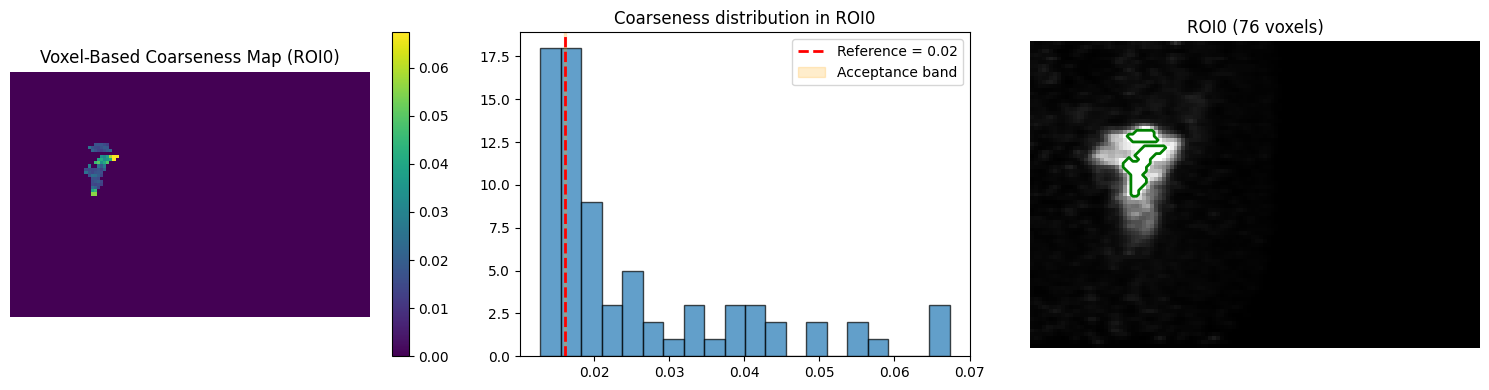

In [53]:
# Extract ROI0 global reference feature and voxel-based map for visualization
img_3d = roi_img[np.newaxis, :, :].astype(np.float32)
mask0_3d = mask0[np.newaxis, :, :].astype(np.uint8)

sitk_img = sitk.GetImageFromArray(img_3d)
sitk_mask0 = sitk.GetImageFromArray(mask0_3d)

reference_result = extractor.execute(sitk_img, sitk_mask0, voxelBased=False)
reference_feature = float(reference_result[FEATURE_KEY])

# Keep the voxel-based map for inspection and plotting
result_roi0 = extractor.execute(sitk_img, sitk_mask0, voxelBased=True)
voxel_map_roi0, bbox_info = reconstruct_voxel_map(result_roi0, roi_img.shape, FEATURE_KEY)
vals_roi0 = voxel_map_roi0[mask0]

print(f"✓ Reference feature computed from ROI0")
print(f"  - Feature: {FEATURE_KEY}")
print(f"  - Reference value: {reference_feature:.6f}")
print(f"  - ROI0 voxels: {mask0.sum()}")
print(f"  - Growing method: {GROWING_METHOD}")
print(f"  - Acceptance method: {ACCEPTANCE_METHOD}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(voxel_map_roi0, cmap="viridis")
axes[0].set_title(f"Voxel-Based {FEATURE_NAME} Map (ROI0)")
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])
axes[0].axis('off')

axes[1].hist(vals_roi0, bins=20, edgecolor='k', alpha=0.7)

reference_tolerance = abs(reference_feature) * (EPSILON if ACCEPTANCE_METHOD == "relative" else THRESHOLD_PERCENT / 100.0)
axes[1].axvline(reference_feature, color='r', linestyle='--', linewidth=2, label=f"Reference = {reference_feature:.2f}")
axes[1].axvspan(
    reference_feature - reference_tolerance,
    reference_feature + reference_tolerance,
    color='orange',
    alpha=0.2,
    label='Acceptance band'
)
axes[1].set_title(f"{FEATURE_NAME} distribution in ROI0")
axes[1].legend()

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='g', linewidths=2)
axes[2].set_title(f"ROI0 ({mask0.sum()} voxels)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 5: Iterative Region Growing

In [54]:
# Iterative region growing with selectable radiomic strategies
roi_final, results, history, stopping_reason = run_region_growing()
print("\n✓ Iterative region growing completed!")
print(f"Stopping reason: {stopping_reason}")

# Create results DataFrame
df_results = pd.DataFrame(results)
print("\nResults Summary:")
print(df_results.to_string(index=False))

Starting Method A growing (15 dilations max)...

Iteración 1: referencia = 0.016172


Iter  1: ROI   76 →   95 | Candidates:   53 | Accepted:   19 | Rejected:   34 | Growth:  +19
Iteración 2: referencia = 0.016757
Iter  2: ROI   95 →  108 | Candidates:   24 | Accepted:   13 | Rejected:   11 | Growth:  +13
Iteración 3: referencia = 0.017624
Iter  3: ROI  108 →  121 | Candidates:   22 | Accepted:   13 | Rejected:    9 | Growth:  +13
Iteración 4: referencia = 0.017946
Iter  4: ROI  121 →  136 | Candidates:   24 | Accepted:   15 | Rejected:    9 | Growth:  +15
Iteración 5: referencia = 0.018768
Iter  5: ROI  136 →  156 | Candidates:   24 | Accepted:   20 | Rejected:    4 | Growth:  +20
Iteración 6: referencia = 0.018694
Iter  6: ROI  156 →  183 | Candidates:   32 | Accepted:   27 | Rejected:    5 | Growth:  +27
Iteración 7: referencia = 0.020331
Iter  7: ROI  183 →  216 | Candidates:   40 | Accepted:   33 | Rejected:    7 | Growth:  +33
Iteración 8: referencia = 0.021881
Iter  8: ROI  216 →  257 | Candidates:   41 | Accepted:   41 | Rejected:    0 | Growth:  +41
Iteración 9

## Stage 6: Results & Visualizations

In [55]:
# Results summary table
print("\n" + "="*80)
print("ITERATIVE REGION GROWING RESULTS")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Summary statistics
roi_final = history[-1]["roi_after"]
total_growth = int(roi_final.sum() - mask0.sum())
percent_growth = (total_growth / mask0.sum()) * 100

print(f"\nFinal Summary:")
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Growing method: {GROWING_METHOD}")
print(f"  - Acceptance method: {ACCEPTANCE_METHOD}")
print(f"  - Initial ROI0 size: {mask0.sum()} voxels")
print(f"  - Final ROI size: {roi_final.sum()} voxels")
print(f"  - Total voxels added: {total_growth} voxels ({percent_growth:.1f}% growth)")
print(f"  - Max dilations: {MAX_DILATIONS}")
print(f"  - Stopping reason: {stopping_reason}")
print(f"  - Reference feature: {reference_feature:.6f}")
print(f"  - Acceptance threshold: {EPSILON if ACCEPTANCE_METHOD == 'relative' else THRESHOLD_PERCENT}")


ITERATIVE REGION GROWING RESULTS
 Iteration  Candidate Voxels  Accepted Voxels  Rejected Voxels  Current ROI Size  New ROI Size  Cumulative Lesion Size  Feature Before  Feature After  Feature Change  Acceptance Metric Mean  Acceptance Metric Min  Acceptance Metric Max  Acceptance Threshold
         1                53               19               34                76            95                      95        0.016172       0.016757        0.000585                1.794952               0.089392               6.686491                     1
         2                24               13               11                95           108                     108        0.016757       0.017624        0.000867                1.018269               0.020549               3.585639                     1
         3                22               13                9               108           121                     121        0.017624       0.017946        0.000322                0.929865   

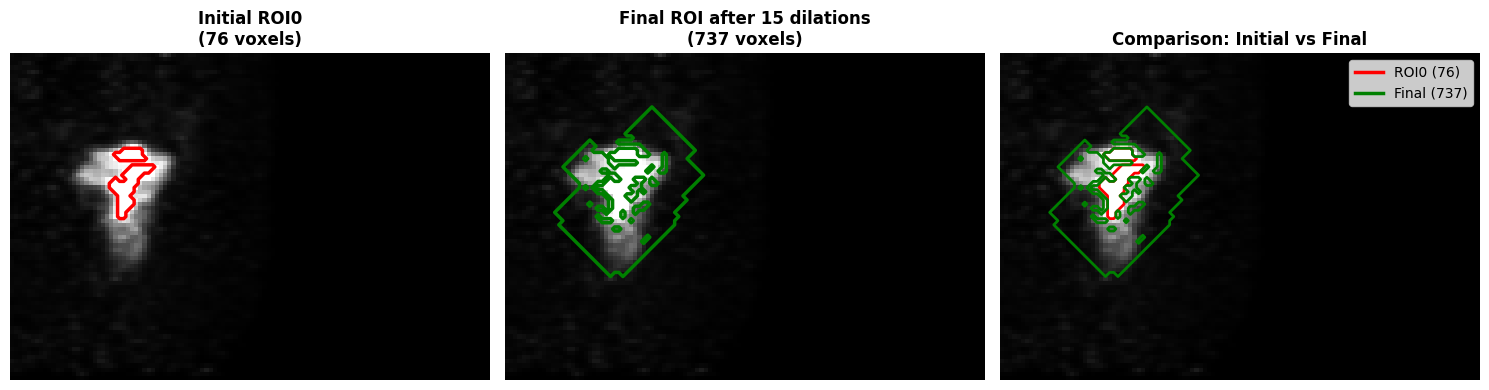

In [56]:
# Visualization: Final ROI evolution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original image with initial mask
axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].contour(mask0, colors='r', linewidths=2.5)
axes[0].set_title(f"Initial ROI0\n({mask0.sum()} voxels)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot 2: Original image with final ROI
axes[1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[1].contour(roi_final, colors='g', linewidths=2.5)
axes[1].set_title(f"Final ROI after {MAX_DILATIONS} dilations\n({roi_final.sum()} voxels)", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Plot 3: Comparison with overlays
axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].contour(roi_final, colors='g', linewidths=2)

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='r', lw=2.5),
    Line2D([0], [0], color='g', lw=2.5)
]
axes[2].legend(custom_lines, [f'ROI0 ({mask0.sum()})', f'Final ({roi_final.sum()})'], 
               loc='upper right', fontsize=10)
axes[2].set_title("Comparison: Initial vs Final", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

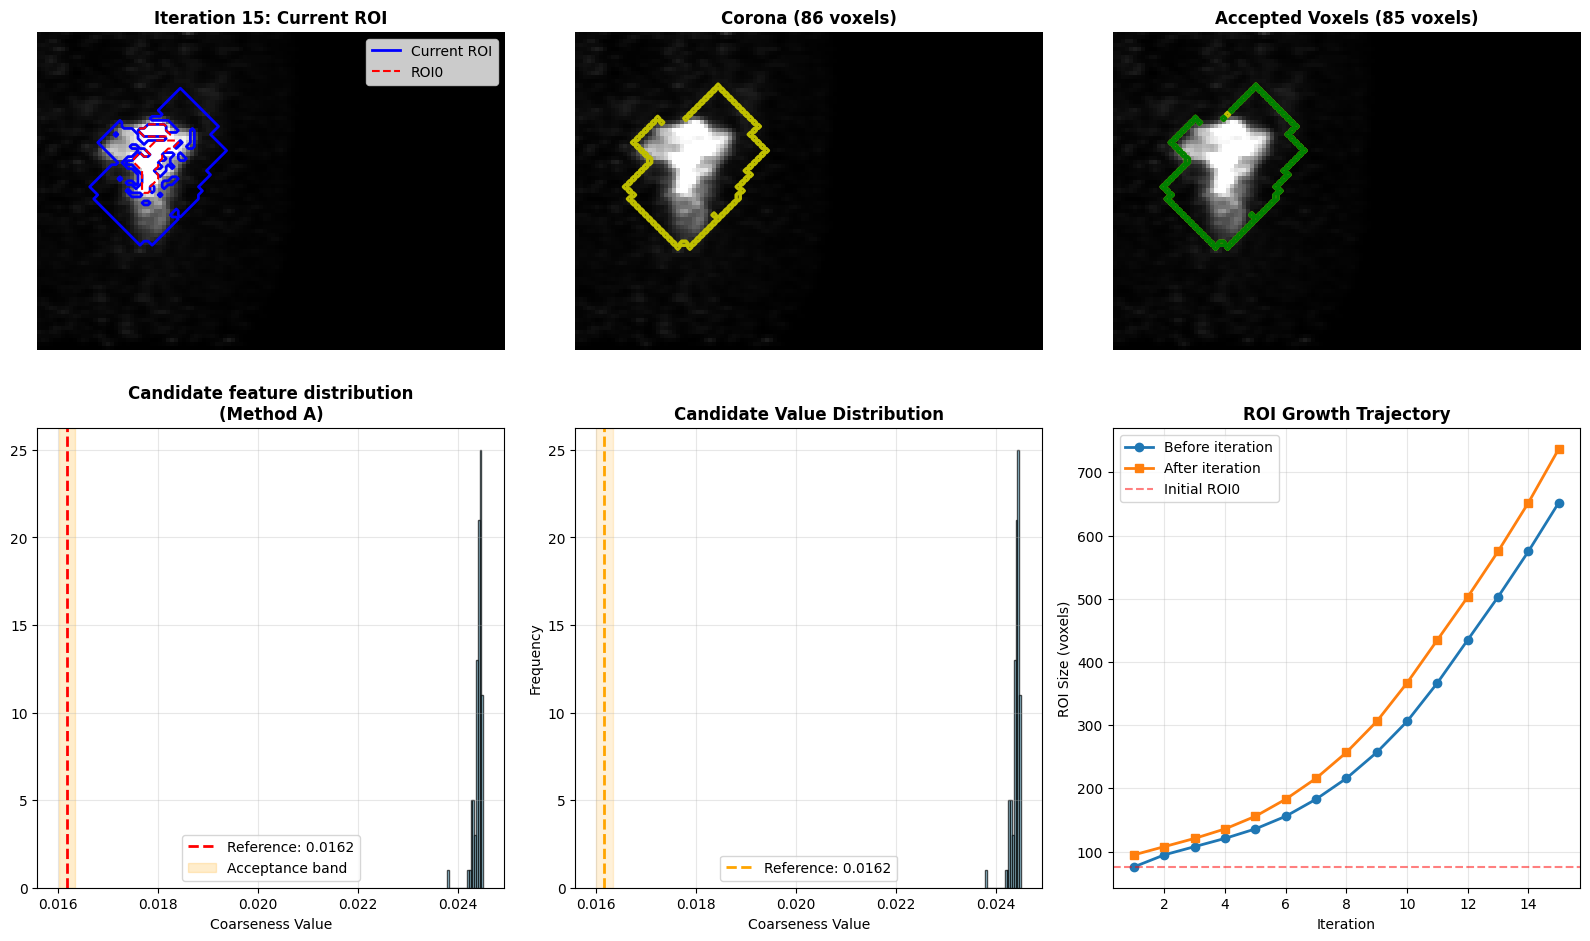

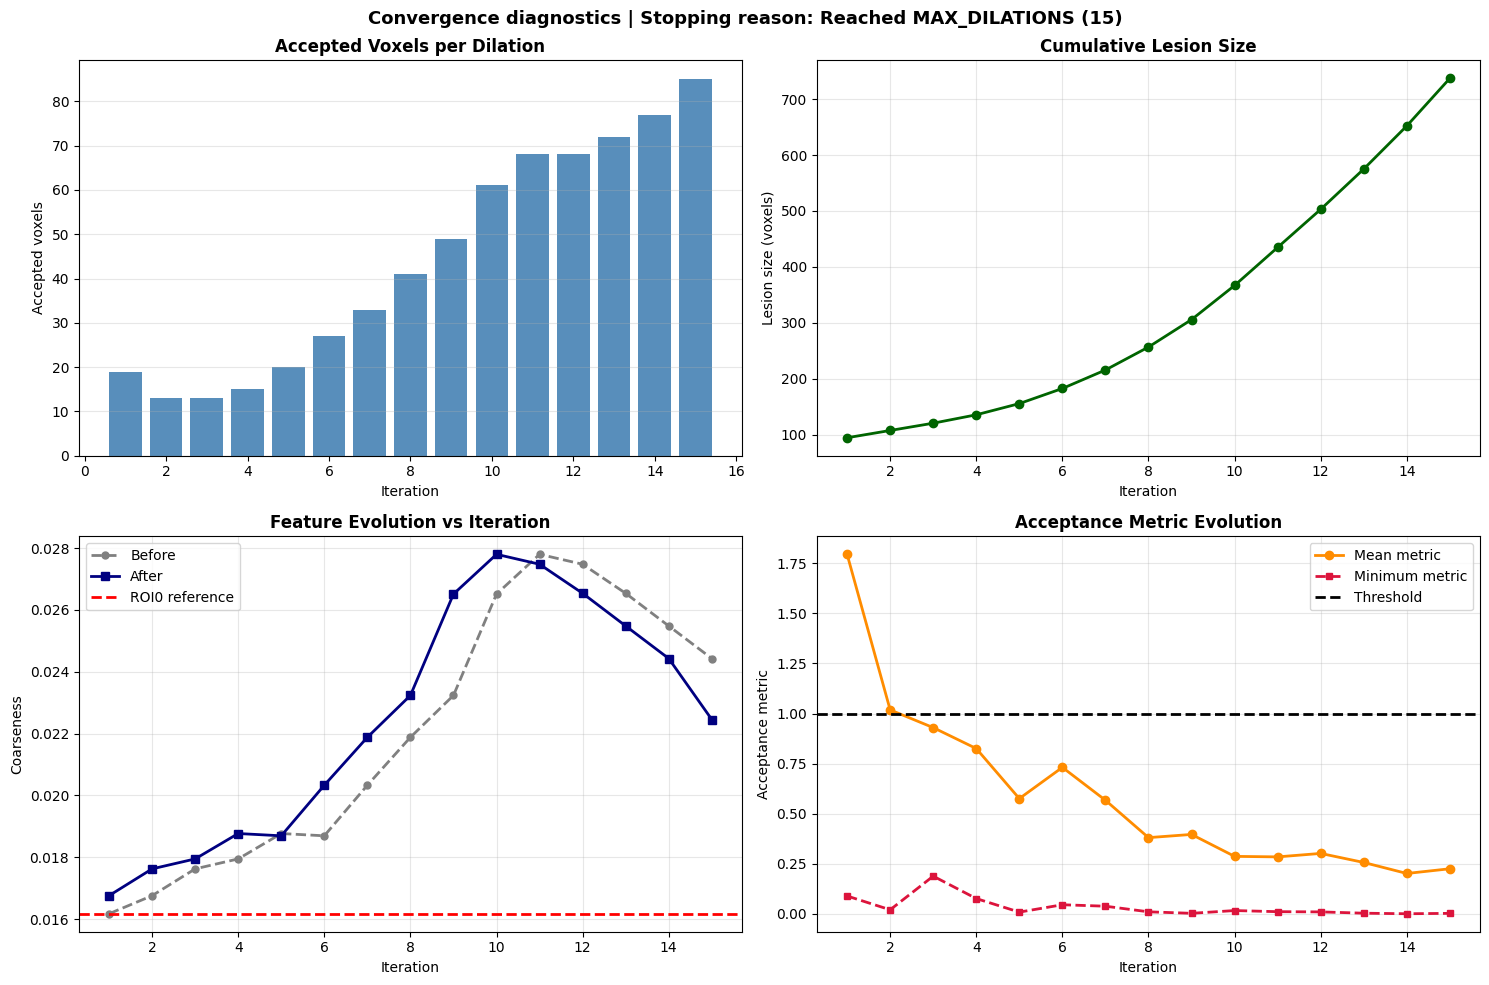

In [57]:
# Detailed visualization of a specific iteration (example: iteration 5)
iter_to_show = min(15, len(history))  # Show iteration 5, or last if fewer iterations
data_iter = history[iter_to_show - 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Iteration details
axes[0, 0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2)
axes[0, 0].contour(mask0, colors='r', linewidths=1.5, linestyles='--')
from matplotlib.lines import Line2D
axes[0, 0].legend(
    [Line2D([0], [0], color='b', lw=2), Line2D([0], [0], color='r', lw=1.5, linestyle='--')],
    ['Current ROI', 'ROI0'],
    loc='upper right'
)
axes[0, 0].set_title(f"Iteration {iter_to_show}: Current ROI", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 1].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 1].set_title(f"Corona ({data_iter['corona'].sum()} voxels)", fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 2].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 2].contour(data_iter["mask_accepted"], colors='g', linewidths=2.5)
axes[0, 2].set_title(f"Accepted Voxels ({data_iter['mask_accepted'].sum()} voxels)", fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Feature map or candidate distribution, plus growth trajectory
candidate_values = np.asarray(data_iter["candidate_values"], dtype=float)
finite_candidate_values = candidate_values[np.isfinite(candidate_values)]
feature_map = data_iter["feature_map"]

if feature_map is not None:
    voxel_map_masked = np.copy(feature_map)
    voxel_map_masked[voxel_map_masked == 0] = np.nan
    im = axes[1, 0].imshow(voxel_map_masked, cmap="viridis")
    axes[1, 0].set_title(f"Voxel-Based {FEATURE_NAME} Map", fontweight='bold')
    plt.colorbar(im, ax=axes[1, 0])
    axes[1, 0].axis('off')
else:
    axes[1, 0].hist(finite_candidate_values, bins=20, edgecolor='k', alpha=0.7, color='skyblue')
    axes[1, 0].axvline(reference_feature, color='r', linestyle='--', linewidth=2, label=f'Reference: {reference_feature:.4f}')
    tolerance = abs(reference_feature) * (EPSILON if ACCEPTANCE_METHOD == "relative" else THRESHOLD_PERCENT / 100.0)
    axes[1, 0].axvspan(reference_feature - tolerance, reference_feature + tolerance, color='orange', alpha=0.2, label='Acceptance band')
    axes[1, 0].set_title(f"Candidate feature distribution\n(Method A)", fontweight='bold')
    axes[1, 0].set_xlabel(f"{FEATURE_NAME} Value")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

if finite_candidate_values.size > 0:
    axes[1, 1].hist(finite_candidate_values, bins=20, edgecolor='k', alpha=0.7, color='skyblue')
    axes[1, 1].axvline(reference_feature, color='orange', linestyle='--', linewidth=2, label=f'Reference: {reference_feature:.4f}')
    tolerance = abs(reference_feature) * (EPSILON if ACCEPTANCE_METHOD == "relative" else THRESHOLD_PERCENT / 100.0)
    axes[1, 1].axvspan(reference_feature - tolerance, reference_feature + tolerance, color='orange', alpha=0.15)
else:
    axes[1, 1].text(0.5, 0.5, "No finite candidate values", ha='center', va='center', transform=axes[1, 1].transAxes)
axes[1, 1].set_xlabel(f"{FEATURE_NAME} Value")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Candidate Value Distribution", fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

iter_range = df_results["Iteration"].to_numpy()
roi_sizes = df_results["Current ROI Size"].to_numpy()
new_sizes = df_results["New ROI Size"].to_numpy()

axes[1, 2].plot(iter_range, roi_sizes, 'o-', linewidth=2, markersize=6, label='Before iteration')
axes[1, 2].plot(iter_range, new_sizes, 's-', linewidth=2, markersize=6, label='After iteration')
axes[1, 2].axhline(mask0.sum(), color='r', linestyle='--', alpha=0.5, label='Initial ROI0')
axes[1, 2].set_xlabel("Iteration")
axes[1, 2].set_ylabel("ROI Size (voxels)")
axes[1, 2].set_title("ROI Growth Trajectory", fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Convergence diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

accepted_voxels = df_results["Accepted Voxels"].to_numpy()
cumulative_size = df_results["Cumulative Lesion Size"].to_numpy()
feature_before = df_results["Feature Before"].to_numpy()
feature_after = df_results["Feature After"].to_numpy()
metric_mean = df_results["Acceptance Metric Mean"].to_numpy()
metric_min = df_results["Acceptance Metric Min"].to_numpy()
metric_threshold = float(df_results["Acceptance Threshold"].dropna().iloc[0]) if df_results["Acceptance Threshold"].notna().any() else np.nan

axes[0, 0].bar(iter_range, accepted_voxels, color='steelblue', alpha=0.9)
axes[0, 0].set_title("Accepted Voxels per Dilation", fontweight='bold')
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Accepted voxels")
axes[0, 0].grid(alpha=0.3, axis='y')

axes[0, 1].plot(iter_range, cumulative_size, 'o-', color='darkgreen', linewidth=2, markersize=6)
axes[0, 1].set_title("Cumulative Lesion Size", fontweight='bold')
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Lesion size (voxels)")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(iter_range, feature_before, 'o--', color='gray', linewidth=2, markersize=5, label='Before')
axes[1, 0].plot(iter_range, feature_after, 's-', color='navy', linewidth=2, markersize=6, label='After')
axes[1, 0].axhline(reference_feature, color='r', linestyle='--', linewidth=2, label='ROI0 reference')
axes[1, 0].set_title("Feature Evolution vs Iteration", fontweight='bold')
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel(FEATURE_NAME)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(iter_range, metric_mean, 'o-', color='darkorange', linewidth=2, markersize=6, label='Mean metric')
axes[1, 1].plot(iter_range, metric_min, 's--', color='crimson', linewidth=2, markersize=5, label='Minimum metric')
if np.isfinite(metric_threshold):
    axes[1, 1].axhline(metric_threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1, 1].set_title("Acceptance Metric Evolution", fontweight='bold')
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Acceptance metric")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

fig.suptitle(f"Convergence diagnostics | Stopping reason: {stopping_reason}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 7: Comparison with manual segmentation

In [58]:
# ==============================================================================
# Stage 7.1: Basic Overlap Analysis
# ==============================================================================

manual = manual_mask_roi.astype(bool)
auto = roi_final.astype(bool)

TP = np.logical_and(manual, auto).sum()
FP = np.logical_and(~manual, auto).sum()
FN = np.logical_and(manual, ~auto).sum()
TN = np.logical_and(~manual, ~auto).sum()

print("="*60)
print("OVERLAP ANALYSIS")
print("="*60)

print(f"Manual voxels:     {manual.sum()}")
print(f"Automatic voxels:  {auto.sum()}")

print()
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")

OVERLAP ANALYSIS
Manual voxels:     318
Automatic voxels:  737

TP: 240
FP: 497
FN: 78
TN: 8349


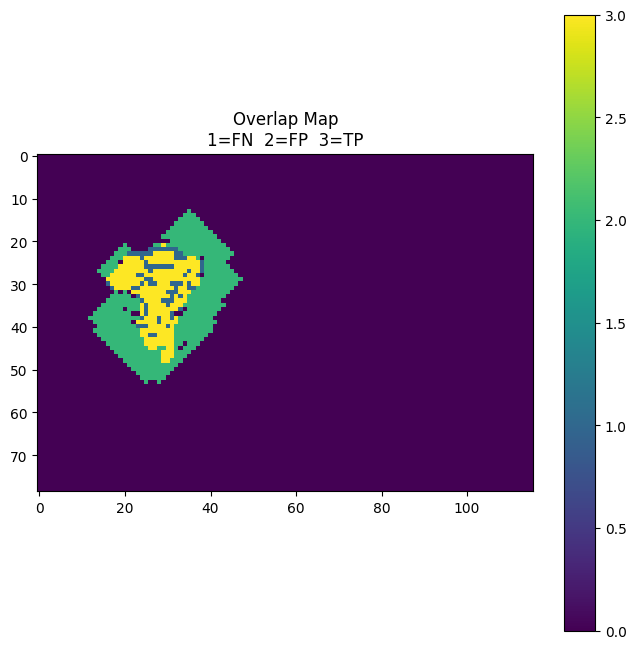

In [59]:
# ==============================================================================
# Visual overlap map
# ==============================================================================

overlap = np.zeros_like(manual, dtype=np.uint8)

overlap[manual & auto] = 3      # TP
overlap[~manual & auto] = 2     # FP
overlap[manual & ~auto] = 1     # FN

plt.figure(figsize=(8,8))

plt.imshow(overlap)

plt.title(
    "Overlap Map\n"
    "1=FN  2=FP  3=TP"
)

plt.colorbar()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_27400\829081298.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(
C:\Users\oscar\AppData\Local\Temp\ipykernel_27400\829081298.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


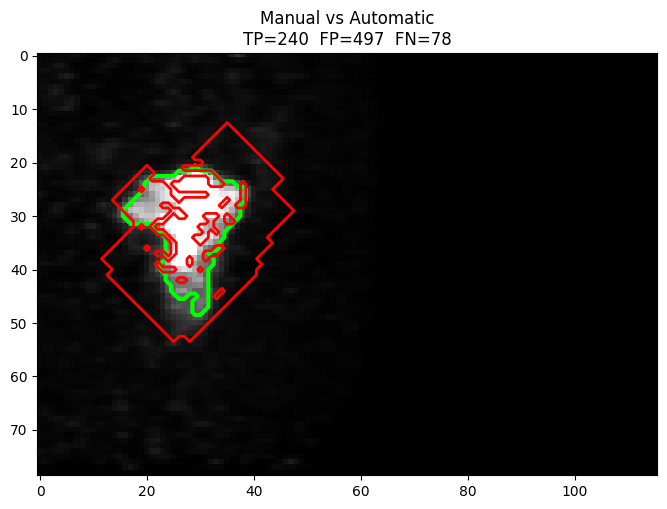

In [60]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(
    manual,
    colors="lime",
    linewidths=3,
    label="Manual"
)

plt.contour(
    auto,
    colors="red",
    linewidths=2,
    label="Automatic"
)

plt.title(
    f"Manual vs Automatic\n"
    f"TP={TP}  FP={FP}  FN={FN}"
)

plt.show()

In [61]:

dice = (2 * TP) / (2 * TP + FP + FN)

iou = TP / (TP + FP + FN)

recall = TP / (TP + FN)

precision = TP / (TP + FP)

metrics_df = pd.DataFrame({
    "Metric": [
        "Dice",
        "IoU",
        "Recall",
        "Precision"
    ],
    "Value": [
        dice,
        iou,
        recall,
        precision
    ]
})

print(f"Final Dice coefficient: {dice:.4f}")

metrics_df

Final Dice coefficient: 0.4550


,Metric,Value
0,Dice,0.454976
1,IoU,0.294479
2,Recall,0.754717
3,Precision,0.325645
